# Adsorption capacity prediction — Random Forest

This notebook trains and evaluates a **Random Forest** regression model for predicting experimental adsorption capacity, $q_e$ (mg g$^{-1}$).

## Analysis workflow
1. Load the audited modeling dataset (`dataset.csv`) and the independent external-validation dataset (`dataset_EV.csv`).
2. Apply the fixed split used in the study: **Training** set (143 records) and **Validation** set (70 records).
3. Train the model using the predefined configuration.
4. Evaluate predictive performance on the **Training**, **Validation**, and **External validation** sets.
5. Perform **repeated 5-fold cross-validation ×10** only on the Training set as the internal validation procedure.
6. Report internal cross-validation metrics as **mean ± standard deviation across 50 validation folds**.
7. Generate residual and applicability-domain diagnostics.
8. Calculate SHAP values on the fixed Validation set for model interpretation.
9. Save all model-specific outputs to one structured results folder on the Desktop.

## Terminology used throughout this notebook
- **Training** — the 143-record subset used for model fitting.
- **Validation** — the fixed 70-record hold-out subset, not used for model fitting or internal cross-validation.
- **External validation** — the independent 19-record dataset.
- **Internal cross-validation (CV)** — RepeatedKFold with 5 folds repeated 10 times on the Training set only, giving 50 validation-fold evaluations.

## Output structure
Running this notebook creates or updates:

`Desktop/Adsorption_qe_ML_results/Random_Forest/`

with three subfolders:
- `Figures/` — publication-quality PNG and PDF figures,
- `Tables/` — CSV tables and a consolidated Excel workbook,
- `Model/` — serialized model and configuration metadata.

The companion notebook writes to the same root folder, so only **one top-level results folder** is created on the Desktop.


## 1. Setup and output directories


In [1]:
MODEL_FOLDER_NAME = "Random_Forest"
MODEL_PREFIX = "RF"
MODEL_DISPLAY_NAME = "Random Forest"

from pathlib import Path
from datetime import datetime
from importlib.metadata import version
import json
import platform

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import shap

from IPython.display import display
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------------
# Reproducible file layout
# ------------------------------------------------------------------

def resolve_input_file(filename):
    """Locate a repository data file or a standalone local copy."""
    cwd = Path.cwd()
    candidates = [
        cwd / filename,
        cwd / "data" / filename,
        cwd.parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return candidates[0]

DATASET_PATH = resolve_input_file("dataset.csv")
EXTERNAL_DATASET_PATH = resolve_input_file("dataset_EV.csv")

def find_desktop():
    """Return a typical Desktop path on Windows, including OneDrive layouts."""
    home = Path.home()

    candidates = [
        home / "Desktop",
        home / "Pulpit",
        home / "OneDrive" / "Desktop",
        home / "OneDrive" / "Pulpit",
    ]

    for one_drive in home.glob("OneDrive*"):
        candidates.extend([
            one_drive / "Desktop",
            one_drive / "Pulpit",
        ])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    fallback = home / "Desktop"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback

DESKTOP = find_desktop()
RESULTS_ROOT = DESKTOP / "Adsorption_qe_ML_results"
MODEL_RESULTS_DIR = RESULTS_ROOT / MODEL_FOLDER_NAME
FIGURES_DIR = MODEL_RESULTS_DIR / "Figures"
TABLES_DIR = MODEL_RESULTS_DIR / "Tables"
MODEL_DIR = MODEL_RESULTS_DIR / "Model"

for folder in [RESULTS_ROOT, MODEL_RESULTS_DIR, FIGURES_DIR, TABLES_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().isoformat(timespec="seconds")

print("Input dataset:", DATASET_PATH)
print("External-validation dataset:", EXTERNAL_DATASET_PATH)
print("Results directory:", MODEL_RESULTS_DIR)

# ------------------------------------------------------------------
# Publication-quality figure style
# ------------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.grid": False,
})

FEATURE_LABELS = {
    "MLOGP": "MLOGP",
    "C0_mg_L": "Initial concentration (mg L$^{-1}$)",
    "pH": "pH",
    "Temperature_C": "Temperature (°C)",
    "Contact_time_min": "Contact time (min)",
    "Dose_g_L": "Adsorbent dose (g L$^{-1}$)",
    "BET_m2_g": "BET surface area (m$^2$ g$^{-1}$)",
    "qe_mg_g": "Adsorption capacity, $q_e$ (mg g$^{-1}$)",
}

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    ax.grid(False)
    return ax

def save_figure_dual(fig, stem):
    """Save a figure directly to the model-specific Figures folder."""
    png_path = FIGURES_DIR / f"{stem}.png"
    pdf_path = FIGURES_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.03)
    return png_path, pdf_path

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

from sklearn.ensemble import RandomForestRegressor

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("Matplotlib:", version("matplotlib"))


Input dataset: C:\Users\DELL\Desktop\dataset.csv
External-validation dataset: C:\Users\DELL\Desktop\dataset_EV.csv
Results directory: C:\Users\DELL\Desktop\Adsorption_qe_ML_results\Random_Forest
Python: 3.13.9
NumPy: 2.3.5
pandas: 2.3.3
scikit-learn: 1.7.2
SHAP: 0.52.0
Matplotlib: 3.10.6


## 2. Load and validate the input data


In [2]:
FEATURES = [
    "MLOGP",
    "C0_mg_L",
    "pH",
    "Temperature_C",
    "Dose_g_L",
    "Contact_time_min",
    "BET_m2_g",
]
TARGET = "qe_mg_g"


# Expected standardized columns
required_columns = FEATURES + [TARGET]

def load_modeling_table(path, label):
    if not path.exists():
        raise FileNotFoundError(
            f"{label} file not found: {path}\n"
            "Place dataset.csv and dataset_EV.csv either in the working directory or in the repository data/ folder."
        )

    table = pd.read_csv(path, sep=";")
    table.columns = table.columns.str.strip()

    missing_columns = [col for col in required_columns if col not in table.columns]
    if missing_columns:
        raise ValueError(
            f"{label} is missing required columns: {missing_columns}"
        )

    # Robust conversion to numeric values without changing valid values.
    for col in required_columns:
        table[col] = (
            table[col]
            .astype(str)
            .str.strip()
            .str.replace(",", ".", regex=False)
        )
        table[col] = pd.to_numeric(table[col], errors="coerce")

    table[required_columns] = table[required_columns].replace(
        [np.inf, -np.inf], np.nan
    )

    invalid = table[table[required_columns].isna().any(axis=1)].copy()
    clean = table.dropna(subset=required_columns).reset_index(drop=True)

    print(f"{label}: {len(clean)} valid records")
    print(f"{label}: {len(invalid)} records removed because of missing/invalid model variables")

    if len(invalid) > 0:
        display(invalid)

    return clean

model_df = load_modeling_table(DATASET_PATH, "Modeling dataset")
external = load_modeling_table(EXTERNAL_DATASET_PATH, "External-validation dataset")

display(model_df.head())


Modeling dataset: 213 valid records
Modeling dataset: 0 records removed because of missing/invalid model variables
External-validation dataset: 19 valid records
External-validation dataset: 0 records removed because of missing/invalid model variables


,MLOGP,C0_mg_L,pH,Temperature_C,Contact_time_min,Dose_g_L,BET_m2_g,qe_mg_g
0,-2.46,5.0,7.0,25,180.0,8.0,1200.00,0.560
1,-2.08,5.0,6.0,25,1440.0,4.0,64.32,1.125
2,-2.46,15.0,7.0,25,180.0,8.0,1200.00,1.779
3,-2.85,5.0,5.5,25,1440.0,2.0,4.30,1.840
4,-2.46,20.0,7.0,25,360.0,8.0,850.00,2.500


## 3. Fixed Training / Validation split


In [3]:
# Fixed split used in the study:
# every third record, starting from the third record, is assigned to the Validation set;
# the final record remains in the Training set.
validation_idx = list(range(2, len(model_df) - 1, 3))

validation_df = model_df.iloc[validation_idx].copy()
train_df = model_df.drop(model_df.index[validation_idx]).copy()

X_train = train_df[FEATURES].copy()
X_validation = validation_df[FEATURES].copy()
X_ext = external[FEATURES].copy()

y_train = train_df[TARGET].copy()
y_validation = validation_df[TARGET].copy()
y_ext = external[TARGET].copy()

print("Training records:", len(train_df))
print("Validation records:", len(validation_df))
print("External-validation records:", len(external))

print("\nTarget range — Training set:")
print("min =", y_train.min(), "max =", y_train.max())

print("\nTarget range — Validation set:")
print("min =", y_validation.min(), "max =", y_validation.max())

print("\nTarget range — External validation set:")
print("min =", y_ext.min(), "max =", y_ext.max())


Training records: 143
Validation records: 70
External-validation records: 19

Target range — Training set:
min = 0.56 max = 675.825

Target range — Validation set:
min = 1.779 max = 522.2

Target range — External validation set:
min = 0.95 max = 723.2


## 4. Train the Random Forest model


In [4]:
MODEL = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1,
)

MODEL.fit(X_train, y_train)
CV_N_JOBS = None

print("The Random Forest model has been trained.")
print("Predictors used by the model:")
print(list(MODEL.feature_names_in_))

feature_importance_table = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": MODEL.feature_importances_,
}).sort_values("Importance", ascending=False)

display(feature_importance_table)


The Random Forest model has been trained.
Predictors used by the model:
['MLOGP', 'C0_mg_L', 'pH', 'Temperature_C', 'Dose_g_L', 'Contact_time_min', 'BET_m2_g']


,Feature,Importance
4,Dose_g_L,0.551452
1,C0_mg_L,0.253292
6,BET_m2_g,0.067222
5,Contact_time_min,0.054848
3,Temperature_C,0.044084
0,MLOGP,0.018678
2,pH,0.010423


## 5. Predictive performance on Training, Validation, and External validation

The **Validation** set is the fixed 70-record hold-out subset. It is not used for model fitting and is kept separate from the repeated internal cross-validation procedure.


In [5]:
# Predictions for the three fixed datasets
y_train_pred = MODEL.predict(X_train)
y_validation_pred = MODEL.predict(X_validation)
y_ext_pred = MODEL.predict(X_ext)

# Metrics for fixed datasets.
metrics_table = pd.DataFrame([
    {
        "Evaluation": "Training",
        "N": len(y_train),
        "R2": r2_score(y_train, y_train_pred),
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "RMSE": rmse(y_train, y_train_pred),
    },
    {
        "Evaluation": "Validation",
        "N": len(y_validation),
        "R2": r2_score(y_validation, y_validation_pred),
        "MAE": mean_absolute_error(y_validation, y_validation_pred),
        "RMSE": rmse(y_validation, y_validation_pred),
    },
    {
        "Evaluation": "External validation",
        "N": len(y_ext),
        "R2": r2_score(y_ext, y_ext_pred),
        "MAE": mean_absolute_error(y_ext, y_ext_pred),
        "RMSE": rmse(y_ext, y_ext_pred),
    },
])

validation_metrics_table = metrics_table.loc[
    metrics_table["Evaluation"] == "Validation"
].copy()

print("FIXED-DATASET PERFORMANCE")
display(
    metrics_table.style.format({
        "R2": "{:.9f}",
        "MAE": "{:.5f}",
        "RMSE": "{:.5f}",
    })
)


FIXED-DATASET PERFORMANCE


,Evaluation,N,R2,MAE,RMSE
0,Training,143,0.930950211,15.15375,30.91693
1,Validation,70,0.703065842,30.79938,54.20537
2,External validation,19,0.758259083,42.90389,75.87144


## 6. Internal validation — repeated 5-fold cross-validation ×10


In [6]:
# Repeated internal cross-validation is performed ONLY on the Training set.
# The fixed Validation and External validation sets remain untouched.
CV_N_SPLITS = 5
CV_N_REPEATS = 10
CV_RANDOM_STATE = 42

cv = RepeatedKFold(
    n_splits=CV_N_SPLITS,
    n_repeats=CV_N_REPEATS,
    random_state=CV_RANDOM_STATE,
)

cv_results = cross_validate(
    MODEL,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
    },
    return_train_score=False,
    n_jobs=CV_N_JOBS,
)

# scikit-learn uses the standard keys "test_*" for the held-out fold
# within cross-validation. Here, these values are internal CV validation-fold
# scores and are unrelated to the fixed Validation set defined above.
cv_r2 = cv_results["test_R2"]
cv_mae = -cv_results["test_MAE"]
cv_rmse = -cv_results["test_RMSE"]

cv_folds_table = pd.DataFrame({
    "Evaluation": np.arange(1, len(cv_r2) + 1),
    "Repeat": np.repeat(
        np.arange(1, CV_N_REPEATS + 1),
        CV_N_SPLITS,
    ),
    "Fold": np.tile(
        np.arange(1, CV_N_SPLITS + 1),
        CV_N_REPEATS,
    ),
    "R2": cv_r2,
    "MAE": cv_mae,
    "RMSE": cv_rmse,
})

cv_summary_table = pd.DataFrame([{
    "Evaluation": "Repeated 5-fold CV ×10",
    "N_evaluations": len(cv_r2),
    "R2_mean": cv_r2.mean(),
    "R2_SD": cv_r2.std(ddof=1),
    "MAE_mean": cv_mae.mean(),
    "MAE_SD": cv_mae.std(ddof=1),
    "RMSE_mean": cv_rmse.mean(),
    "RMSE_SD": cv_rmse.std(ddof=1),
    "Performed_on": "Training set only",
}])

# A single numeric summary table for export.
performance_summary_table = pd.DataFrame([
    {
        "Evaluation": "Training",
        "N_or_evaluations": len(y_train),
        "R2": r2_score(y_train, y_train_pred),
        "R2_SD": np.nan,
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "MAE_SD": np.nan,
        "RMSE": rmse(y_train, y_train_pred),
        "RMSE_SD": np.nan,
        "Notes": "Model fitted on this dataset.",
    },
    {
        "Evaluation": "Validation",
        "N_or_evaluations": len(y_validation),
        "R2": r2_score(y_validation, y_validation_pred),
        "R2_SD": np.nan,
        "MAE": mean_absolute_error(y_validation, y_validation_pred),
        "MAE_SD": np.nan,
        "RMSE": rmse(y_validation, y_validation_pred),
        "RMSE_SD": np.nan,
        "Notes": "Fixed hold-out validation set; not used for model fitting or internal CV.",
    },
    {
        "Evaluation": "External validation",
        "N_or_evaluations": len(y_ext),
        "R2": r2_score(y_ext, y_ext_pred),
        "R2_SD": np.nan,
        "MAE": mean_absolute_error(y_ext, y_ext_pred),
        "MAE_SD": np.nan,
        "RMSE": rmse(y_ext, y_ext_pred),
        "RMSE_SD": np.nan,
        "Notes": "Independent external-validation dataset.",
    },
    {
        "Evaluation": "Repeated 5-fold CV ×10",
        "N_or_evaluations": len(cv_r2),
        "R2": cv_r2.mean(),
        "R2_SD": cv_r2.std(ddof=1),
        "MAE": cv_mae.mean(),
        "MAE_SD": cv_mae.std(ddof=1),
        "RMSE": cv_rmse.mean(),
        "RMSE_SD": cv_rmse.std(ddof=1),
        "Notes": "Mean ± sample SD across 50 internal validation folds; performed on Training set only.",
    },
])

# Publication-friendly display: fixed datasets are point estimates;
# internal CV is shown as mean ± SD across the 50 validation folds.
performance_display = pd.DataFrame([
    {
        "Evaluation": "Training",
        "N / evaluations": str(len(y_train)),
        "R2": f"{r2_score(y_train, y_train_pred):.6f}",
        "MAE": f"{mean_absolute_error(y_train, y_train_pred):.5f}",
        "RMSE": f"{rmse(y_train, y_train_pred):.5f}",
    },
    {
        "Evaluation": "Validation",
        "N / evaluations": str(len(y_validation)),
        "R2": f"{r2_score(y_validation, y_validation_pred):.6f}",
        "MAE": f"{mean_absolute_error(y_validation, y_validation_pred):.5f}",
        "RMSE": f"{rmse(y_validation, y_validation_pred):.5f}",
    },
    {
        "Evaluation": "External validation",
        "N / evaluations": str(len(y_ext)),
        "R2": f"{r2_score(y_ext, y_ext_pred):.6f}",
        "MAE": f"{mean_absolute_error(y_ext, y_ext_pred):.5f}",
        "RMSE": f"{rmse(y_ext, y_ext_pred):.5f}",
    },
    {
        "Evaluation": "Repeated 5-fold CV ×10",
        "N / evaluations": f"{len(cv_r2)} folds",
        "R2": f"{cv_r2.mean():.6f} ± {cv_r2.std(ddof=1):.6f}",
        "MAE": f"{cv_mae.mean():.5f} ± {cv_mae.std(ddof=1):.5f}",
        "RMSE": f"{cv_rmse.mean():.5f} ± {cv_rmse.std(ddof=1):.5f}",
    },
])

print(f"Internal validation: repeated {CV_N_SPLITS}-fold cross-validation ×{CV_N_REPEATS}")
print("Number of validation-fold evaluations:", len(cv_r2))
print("Cross-validation metrics are reported as mean ± sample SD across the 50 validation folds.")
display(performance_display)


Internal validation: repeated 5-fold cross-validation ×10
Number of validation-fold evaluations: 50
Cross-validation metrics are reported as mean ± sample SD across the 50 validation folds.


,Evaluation,N / evaluations,R2,MAE,RMSE
0,Training,143,0.930950,15.15375,30.91693
1,Validation,70,0.703066,30.79938,54.20537
2,External validation,19,0.758259,42.90389,75.87144
3,Repeated 5-fold CV ×10,50 folds,0.718536 ± 0.213653,31.26913 ± 8.74676,55.88816 ± 18.04339


## 7. Observed versus predicted values


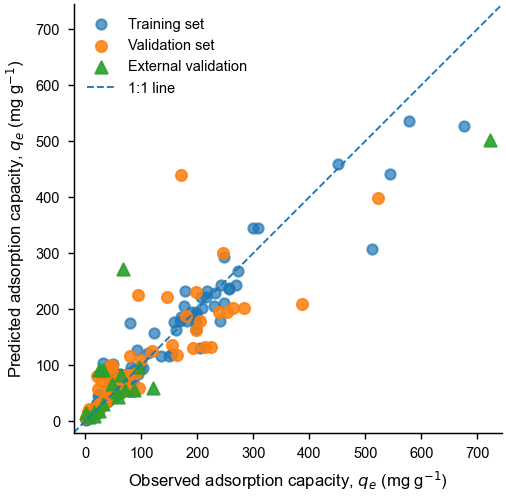

In [7]:
fig, ax = plt.subplots(figsize=(3.55, 3.55))

ax.scatter(y_train, y_train_pred, s=24, alpha=0.70, label="Training set")
ax.scatter(y_validation, y_validation_pred, s=28, alpha=0.85, label="Validation set")
ax.scatter(y_ext, y_ext_pred, s=34, marker="^", alpha=0.90, label="External validation")

all_observed = np.concatenate([
    np.asarray(y_train),
    np.asarray(y_validation),
    np.asarray(y_ext),
])
all_predicted = np.concatenate([
    np.asarray(y_train_pred),
    np.asarray(y_validation_pred),
    np.asarray(y_ext_pred),
])

plot_min = min(all_observed.min(), all_predicted.min())
plot_max = max(all_observed.max(), all_predicted.max())
margin = 0.03 * (plot_max - plot_min if plot_max > plot_min else 1.0)
plot_min -= margin
plot_max += margin

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=0.9,
    label="1:1 line",
)

ax.set_xlim(plot_min, plot_max)
ax.set_ylim(plot_min, plot_max)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Observed adsorption capacity, $q_e$ (mg g$^{-1}$)")
ax.set_ylabel("Predicted adsorption capacity, $q_e$ (mg g$^{-1}$)")
ax.legend(frameon=False, loc="best")
clean_axes(ax)
fig.tight_layout()

save_figure_dual(fig, f"{MODEL_PREFIX}_observed_vs_predicted")
plt.show()
plt.close(fig)


## 8. Residual analysis


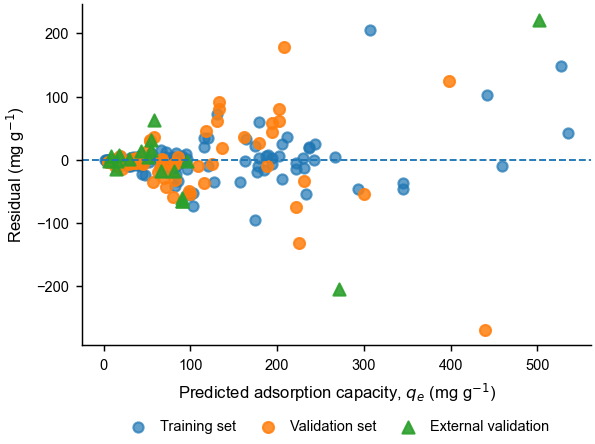

In [8]:
# Residual = observed - predicted
residuals_train = np.asarray(y_train) - np.asarray(y_train_pred)
residuals_validation = np.asarray(y_validation) - np.asarray(y_validation_pred)
residuals_ext = np.asarray(y_ext) - np.asarray(y_ext_pred)

fig, ax = plt.subplots(figsize=(4.15, 3.15))

ax.scatter(y_train_pred, residuals_train, s=24, alpha=0.70, label="Training set")
ax.scatter(y_validation_pred, residuals_validation, s=28, alpha=0.85, label="Validation set")
ax.scatter(y_ext_pred, residuals_ext, s=34, marker="^", alpha=0.90, label="External validation")

ax.axhline(0, linestyle="--", linewidth=0.9)
ax.set_xlabel("Predicted adsorption capacity, $q_e$ (mg g$^{-1}$)")
ax.set_ylabel("Residual (mg g$^{-1}$)")
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    handletextpad=0.5,
    columnspacing=1.2,
)
clean_axes(ax)
fig.tight_layout()
fig.subplots_adjust(bottom=0.24)

save_figure_dual(fig, f"{MODEL_PREFIX}_residuals_vs_predicted")
plt.show()
plt.close(fig)


## 9. Applicability-domain diagnostic


Number of training records: 143
Number of predictors: 7
Leverage threshold h* = 0.1678
Training-set RMSE = 30.9169


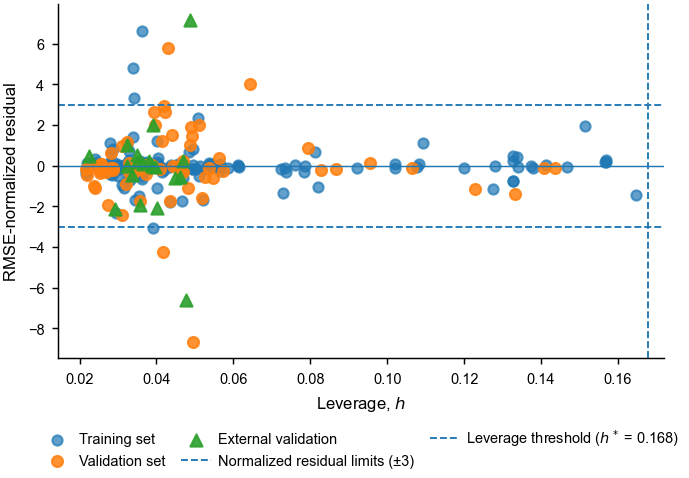

External records inside the applicability domain: 17 / 19


,MLOGP,C0_mg_L,pH,Temperature_C,Dose_g_L,Contact_time_min,BET_m2_g,qe_mg_g,Predicted_qe_mg_g,Leverage,Normalized_residual
0,-2.46,100.0,7.0,20.0,0.125,50,988.00,723.20,501.397058,0.048603,7.174158
2,-2.46,25.0,4.0,30.0,0.100,180,865.06,66.46,270.948069,0.047654,-6.614113


In [9]:
# The diagnostic uses leverage in standardized predictor space and
# RMSE-normalized residuals. The leverage threshold is h* = 3(p + 1) / n.

scaler_ad = StandardScaler()
X_train_scaled = scaler_ad.fit_transform(X_train)
X_validation_scaled = scaler_ad.transform(X_validation)
X_ext_scaled = scaler_ad.transform(X_ext)

# Add an intercept column to each standardized design matrix.
X_train_design = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_validation_design = np.column_stack([np.ones(len(X_validation_scaled)), X_validation_scaled])
X_ext_design = np.column_stack([np.ones(len(X_ext_scaled)), X_ext_scaled])

xtx_inverse = np.linalg.pinv(X_train_design.T @ X_train_design)

h_train = np.diag(X_train_design @ xtx_inverse @ X_train_design.T)
h_validation = np.einsum("ij,jk,ik->i", X_validation_design, xtx_inverse, X_validation_design)
h_ext = np.einsum("ij,jk,ik->i", X_ext_design, xtx_inverse, X_ext_design)

n_train = len(X_train)
p = len(FEATURES)
h_star = 3 * (p + 1) / n_train

rmse_train = rmse(y_train, y_train_pred)
if rmse_train == 0:
    raise ValueError("Training-set RMSE is 0; normalized residuals cannot be calculated.")

std_res_train = residuals_train / rmse_train
std_res_validation = residuals_validation / rmse_train
std_res_ext = residuals_ext / rmse_train

print("Number of training records:", n_train)
print("Number of predictors:", p)
print("Leverage threshold h* =", round(h_star, 4))
print("Training-set RMSE =", round(rmse_train, 4))

fig, ax = plt.subplots(figsize=(4.9, 3.45))

ax.scatter(h_train, std_res_train, s=24, alpha=0.70, label="Training set")
ax.scatter(h_validation, std_res_validation, s=28, alpha=0.85, label="Validation set")
ax.scatter(h_ext, std_res_ext, s=34, marker="^", alpha=0.90, label="External validation")

ax.axhline(0, linewidth=0.7)
ax.axhline(3, linestyle="--", linewidth=0.9, label="Normalized residual limits (±3)")
ax.axhline(-3, linestyle="--", linewidth=0.9)
ax.axvline(
    h_star,
    linestyle="--",
    linewidth=0.9,
    label=f"Leverage threshold ($h^*$ = {h_star:.3f})",
)

ax.set_xlabel("Leverage, $h$")
ax.set_ylabel("RMSE-normalized residual")
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    handletextpad=0.5,
    columnspacing=1.1,
    borderaxespad=0,
)
clean_axes(ax)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)

save_figure_dual(fig, f"{MODEL_PREFIX}_leverage_residual_applicability_domain")
plt.show()
plt.close(fig)

external_ad = external.copy()
external_ad["Predicted_qe_mg_g"] = y_ext_pred
external_ad["Residual_mg_g"] = residuals_ext
external_ad["Normalized_residual"] = std_res_ext
external_ad["Leverage"] = h_ext
external_ad["High_leverage"] = external_ad["Leverage"] > h_star
external_ad["Large_residual"] = np.abs(external_ad["Normalized_residual"]) > 3
external_ad["Inside_AD"] = ~(external_ad["High_leverage"] | external_ad["Large_residual"])

print(
    "External records inside the applicability domain:",
    int(external_ad["Inside_AD"].sum()),
    "/",
    len(external_ad),
)

columns_to_show = FEATURES + [
    TARGET,
    "Predicted_qe_mg_g",
    "Leverage",
    "Normalized_residual",
]

display(
    external_ad.loc[
        ~external_ad["Inside_AD"],
        columns_to_show,
    ]
)


## 10. SHAP interpretation on the Validation set


In [10]:
# SHAP values are calculated on the fixed Validation set (70-record Validation subset).
print("SHAP version:", shap.__version__)

explainer = shap.TreeExplainer(
    MODEL,
    feature_perturbation="tree_path_dependent",
    model_output="raw",
)

shap_values_validation = np.asarray(
    explainer.shap_values(X_validation, check_additivity=True)
)

expected_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
shap_reconstructed = expected_value + shap_values_validation.sum(axis=1)
SHAP_MAX_ADDITIVITY_DIFFERENCE = float(
    np.max(np.abs(np.asarray(y_validation_pred) - shap_reconstructed))
)

print("Maximum SHAP additivity difference:", SHAP_MAX_ADDITIVITY_DIFFERENCE)


SHAP version: 0.52.0
Maximum SHAP additivity difference: 1.9326762412674725e-12


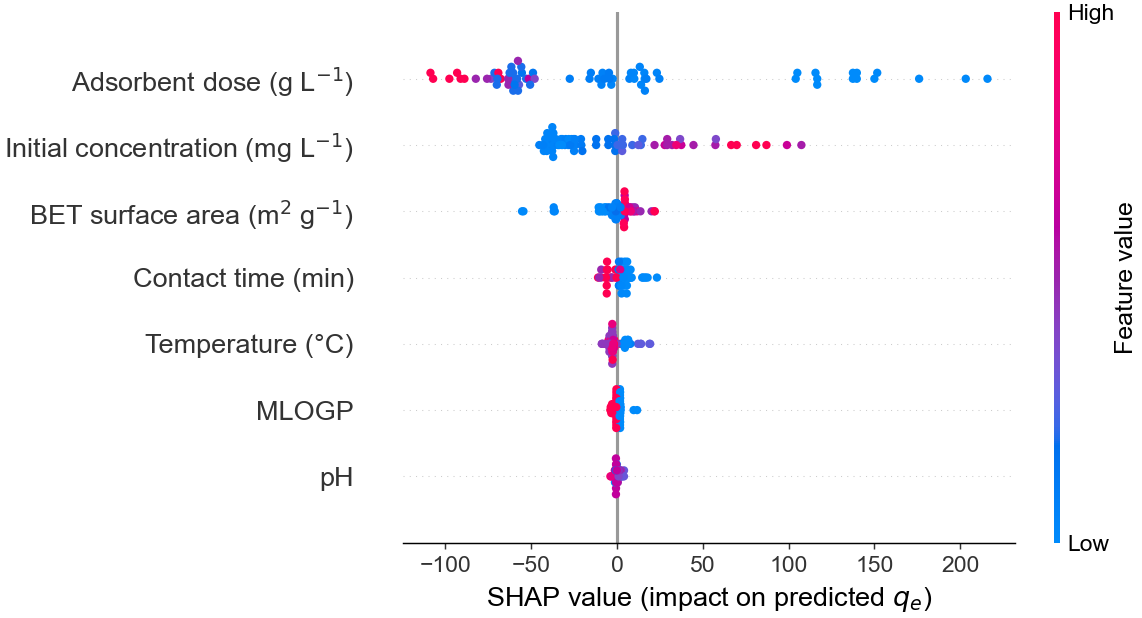

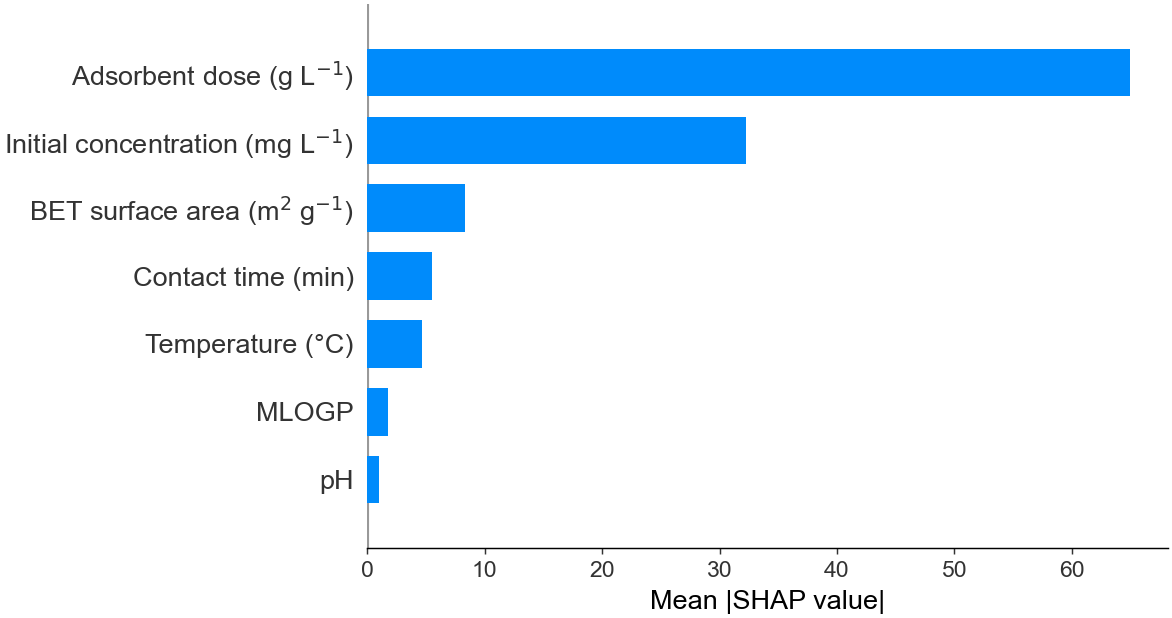

,Feature,Mean_absolute_SHAP
4,Dose_g_L,64.978346
1,C0_mg_L,32.228976
6,BET_m2_g,8.360149
5,Contact_time_min,5.551543
3,Temperature_C,4.646962
0,MLOGP,1.782512
2,pH,1.004193


Predictors selected for SHAP dependence plots: ['Dose_g_L', 'C0_mg_L', 'BET_m2_g']


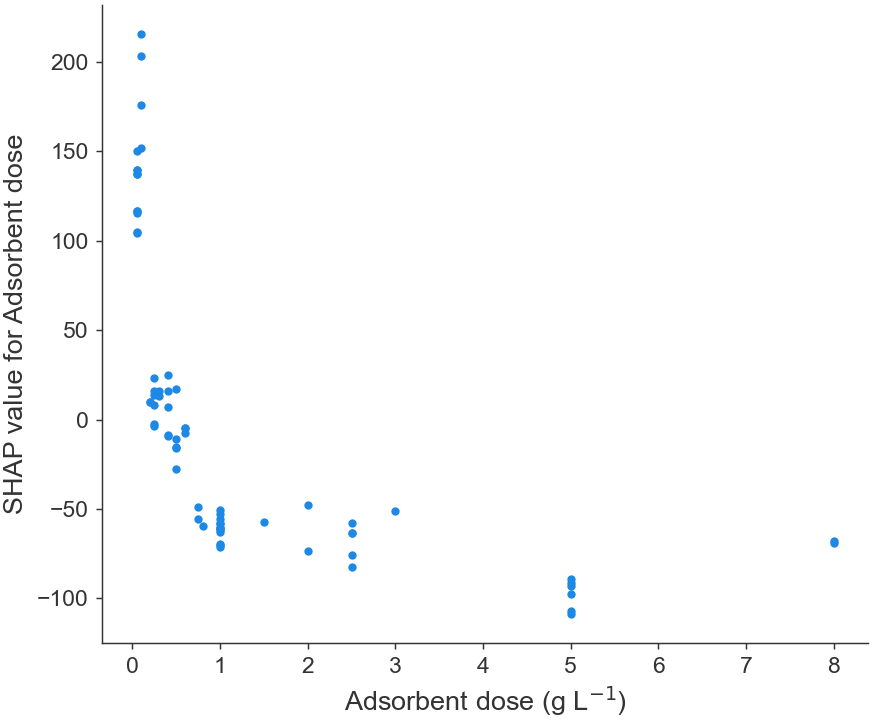

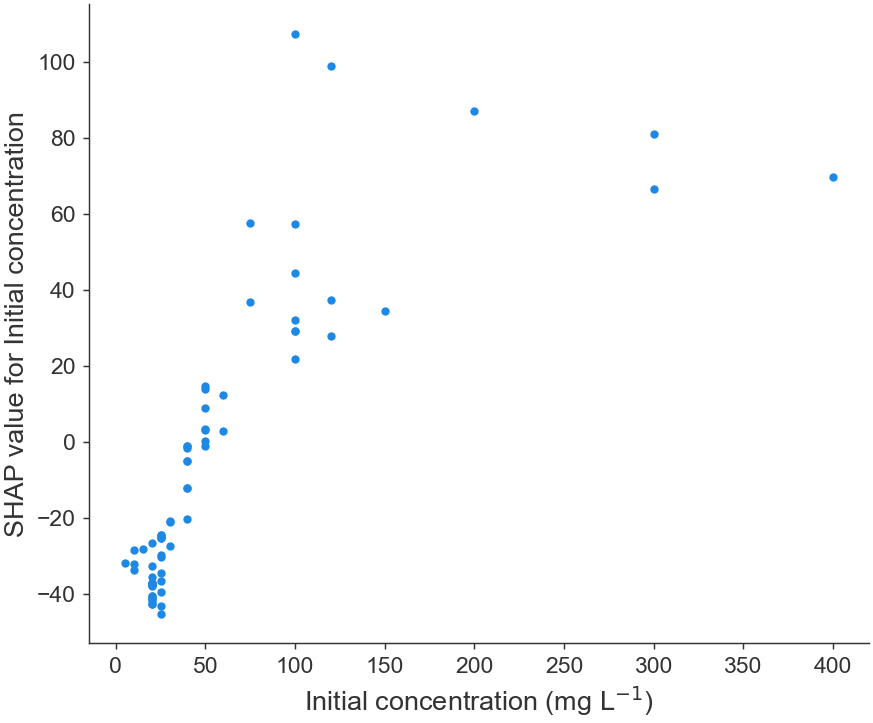

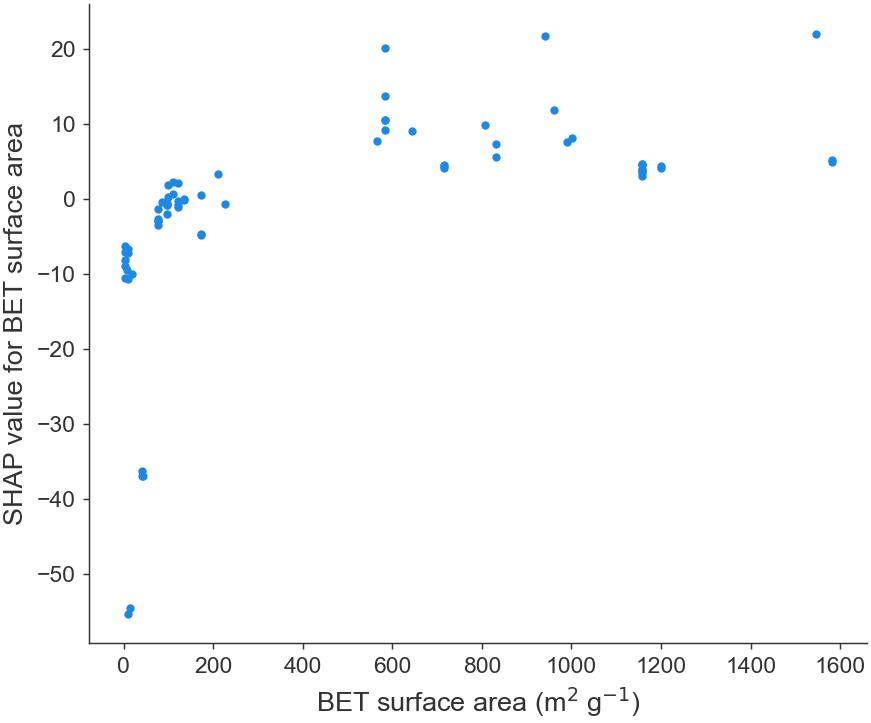

In [11]:
X_validation_display = X_validation.copy()
X_validation_display.columns = [FEATURE_LABELS.get(col, col) for col in X_validation_display.columns]

# SHAP beeswarm summary
shap.summary_plot(
    shap_values_validation,
    X_validation_display,
    show=False,
)
fig = plt.gcf()
ax = plt.gca()
ax.set_xlabel("SHAP value (impact on predicted $q_e$)")
clean_axes(ax)
fig.tight_layout()
save_figure_dual(fig, f"{MODEL_PREFIX}_SHAP_summary")
plt.show()
plt.close(fig)

# Mean absolute SHAP importance
shap.summary_plot(
    shap_values_validation,
    X_validation_display,
    plot_type="bar",
    show=False,
)
fig = plt.gcf()
ax = plt.gca()
ax.set_xlabel("Mean |SHAP value|")
clean_axes(ax)
fig.tight_layout()
save_figure_dual(fig, f"{MODEL_PREFIX}_SHAP_importance")
plt.show()
plt.close(fig)

mean_abs_shap = np.abs(shap_values_validation).mean(axis=0)
shap_importance_table = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_absolute_SHAP": mean_abs_shap,
}).sort_values("Mean_absolute_SHAP", ascending=False)

display(shap_importance_table)

# Dependence plots for the three most important predictors.
top_features = shap_importance_table["Feature"].head(min(3, len(FEATURES))).tolist()
print("Predictors selected for SHAP dependence plots:", top_features)

for rank, feature_name in enumerate(top_features, start=1):
    shap.dependence_plot(
        feature_name,
        shap_values_validation,
        X_validation,
        interaction_index=None,
        show=False,
    )
    fig = plt.gcf()
    ax = plt.gca()
    ax.set_xlabel(FEATURE_LABELS.get(feature_name, feature_name))
    short_label = FEATURE_LABELS.get(feature_name, feature_name).split(" (")[0]
    ax.set_ylabel(f"SHAP value for {short_label}")
    clean_axes(ax)
    fig.tight_layout()

    safe_name = feature_name.replace(" ", "_").replace("/", "_")
    save_figure_dual(
        fig,
        f"{MODEL_PREFIX}_SHAP_dependence_{rank}_{safe_name}",
    )
    plt.show()
    plt.close(fig)


## 11. Export all results


In [12]:
# ------------------------------------------------------------------
# Tables
# ------------------------------------------------------------------

train_results = train_df.copy()
train_results["Observed_qe_mg_g"] = np.asarray(y_train)
train_results["Predicted_qe_mg_g"] = np.asarray(y_train_pred)
train_results["Residual_mg_g"] = np.asarray(residuals_train)

validation_results = validation_df.copy()
validation_results["Observed_qe_mg_g"] = np.asarray(y_validation)
validation_results["Predicted_qe_mg_g"] = np.asarray(y_validation_pred)
validation_results["Residual_mg_g"] = np.asarray(residuals_validation)

external_results = external.copy()
external_results["Observed_qe_mg_g"] = np.asarray(y_ext)
external_results["Predicted_qe_mg_g"] = np.asarray(y_ext_pred)
external_results["Residual_mg_g"] = np.asarray(residuals_ext)

shap_values_table = pd.DataFrame(shap_values_validation, columns=FEATURES)
shap_values_table.insert(0, "Validation_row_index", validation_df.index.to_numpy())

table_exports = {
    f"{MODEL_PREFIX}_performance_summary.csv": performance_summary_table,
    f"{MODEL_PREFIX}_fixed_dataset_metrics.csv": metrics_table,
    f"{MODEL_PREFIX}_validation_metrics.csv": validation_metrics_table,
    f"{MODEL_PREFIX}_cross_validation_folds.csv": cv_folds_table,
    f"{MODEL_PREFIX}_cross_validation_summary.csv": cv_summary_table,
    f"{MODEL_PREFIX}_feature_importance.csv": feature_importance_table,
    f"{MODEL_PREFIX}_SHAP_importance.csv": shap_importance_table,
    f"{MODEL_PREFIX}_SHAP_values_validation.csv": shap_values_table,
    f"{MODEL_PREFIX}_predictions_training.csv": train_results,
    f"{MODEL_PREFIX}_predictions_validation.csv": validation_results,
    f"{MODEL_PREFIX}_predictions_external_validation.csv": external_results,
    f"{MODEL_PREFIX}_external_applicability_domain.csv": external_ad,
}

for filename, table in table_exports.items():
    table.to_csv(TABLES_DIR / filename, index=False)

# Consolidated Excel workbook
excel_path = MODEL_RESULTS_DIR / f"{MODEL_PREFIX}_qe_complete_results.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    performance_summary_table.to_excel(writer, sheet_name="Performance_summary", index=False)
    metrics_table.to_excel(writer, sheet_name="Fixed_dataset_metrics", index=False)
    validation_metrics_table.to_excel(writer, sheet_name="Validation_metrics", index=False)
    cv_folds_table.to_excel(writer, sheet_name="CV_folds", index=False)
    cv_summary_table.to_excel(writer, sheet_name="CV_summary", index=False)
    feature_importance_table.to_excel(writer, sheet_name="Feature_importance", index=False)
    shap_importance_table.to_excel(writer, sheet_name="SHAP_importance", index=False)
    shap_values_table.to_excel(writer, sheet_name="SHAP_values_validation", index=False)
    train_results.to_excel(writer, sheet_name="Predictions_training", index=False)
    validation_results.to_excel(writer, sheet_name="Predictions_validation", index=False)
    external_results.to_excel(writer, sheet_name="Predictions_external", index=False)
    external_ad.to_excel(writer, sheet_name="External_AD", index=False)

# ------------------------------------------------------------------
# Model and configuration
# ------------------------------------------------------------------

joblib_model_path = MODEL_DIR / 'RandomForest_qe_model.joblib'
joblib.dump(MODEL, joblib_model_path)

configuration = {
    "run_timestamp": RUN_TIMESTAMP,
    "dataset_file": DATASET_PATH.name,
    "external_validation_file": EXTERNAL_DATASET_PATH.name,
    "features": FEATURES,
    "target": TARGET,
    "split_rule": "validation_idx = list(range(2, len(model_df) - 1, 3))",
    "split_terminology": {
        "training": "143-record subset used for model fitting",
        "validation": "fixed 70-record hold-out subset, not used for fitting or internal CV",
        "external_validation": "independent 19-record dataset",
    },
    "model_parameters": MODEL.get_params(deep=False),
    "n_training": int(len(train_df)),
    "n_validation": int(len(validation_df)),
    "n_external_validation": int(len(external)),
    "fixed_dataset_performance": {
        row["Evaluation"]: {
            "N": int(row["N"]),
            "R2": float(row["R2"]),
            "MAE": float(row["MAE"]),
            "RMSE": float(row["RMSE"]),
        }
        for row in metrics_table.to_dict(orient="records")
    },
    "internal_cross_validation": {
        "method": "RepeatedKFold",
        "n_splits": CV_N_SPLITS,
        "n_repeats": CV_N_REPEATS,
        "n_validation_fold_evaluations": int(len(cv_r2)),
        "random_state": CV_RANDOM_STATE,
        "performed_on": "Training set only",
        "reporting": "mean ± sample standard deviation across 50 validation folds",
        "R2_mean": float(cv_r2.mean()),
        "R2_SD": float(cv_r2.std(ddof=1)),
        "MAE_mean": float(cv_mae.mean()),
        "MAE_SD": float(cv_mae.std(ddof=1)),
        "RMSE_mean": float(cv_rmse.mean()),
        "RMSE_SD": float(cv_rmse.std(ddof=1)),
    },
    "applicability_domain": {
        "method": "standardized predictor-space leverage + RMSE-normalized residual",
        "leverage_threshold_h_star": float(h_star),
        "residual_limit": 3.0,
    },
    "software_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "shap": shap.__version__,
        "matplotlib": version("matplotlib"),
        
    },
    "SHAP": {
        "explainer": "shap.TreeExplainer",
        "feature_perturbation": "tree_path_dependent",
        "model_output": "raw",
        "check_additivity": True,
        "evaluation_dataset": "Validation",
        "max_additivity_difference": float(SHAP_MAX_ADDITIVITY_DIFFERENCE),
    },
}

configuration_path = MODEL_DIR / 'RandomForest_configuration.json'
with open(configuration_path, "w", encoding="utf-8") as file:
    json.dump(configuration, file, ensure_ascii=False, indent=2, default=str)

print("=" * 78)
print(f"{MODEL_DISPLAY_NAME.upper()} ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 78)
print("\nResults directory:")
print(MODEL_RESULTS_DIR)
print("\nSaved output groups:")
print(f"- Figures: {FIGURES_DIR}")
print(f"- Tables:  {TABLES_DIR}")
print(f"- Model:   {MODEL_DIR}")
print(f"- Consolidated workbook: {excel_path.name}")

print("\nFINAL PERFORMANCE SUMMARY")
display(performance_display)


RANDOM FOREST ANALYSIS COMPLETED SUCCESSFULLY

Results directory:
C:\Users\DELL\Desktop\Adsorption_qe_ML_results\Random_Forest

Saved output groups:
- Figures: C:\Users\DELL\Desktop\Adsorption_qe_ML_results\Random_Forest\Figures
- Tables:  C:\Users\DELL\Desktop\Adsorption_qe_ML_results\Random_Forest\Tables
- Model:   C:\Users\DELL\Desktop\Adsorption_qe_ML_results\Random_Forest\Model
- Consolidated workbook: RF_qe_complete_results.xlsx

FINAL PERFORMANCE SUMMARY


,Evaluation,N / evaluations,R2,MAE,RMSE
0,Training,143,0.930950,15.15375,30.91693
1,Validation,70,0.703066,30.79938,54.20537
2,External validation,19,0.758259,42.90389,75.87144
3,Repeated 5-fold CV ×10,50 folds,0.718536 ± 0.213653,31.26913 ± 8.74676,55.88816 ± 18.04339
